In [2]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox, Trajectories
import optimal.metrics as metrics
import numpy as np
import time

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = Trajectories.joint_6dof
nq = len(robot_pin_model.q_indices)
nv = len(robot_pin_model.v_indices)

MAX_ERROR_DEG = 0.5  # hard ceiling on the position error

def evaluate(kp, kd, DT, path, time_limit=1000, max_error_deg=MAX_ERROR_DEG, get_xs_us=False, alpha=1.0, interpolation="quintic"):
    controller = RobotController(robot_pin_model)
    xs, us = [], []
    try:
        current_q = path[0]
        current_v = np.zeros(nv)
        for i in range(1, len(path)):
            x_start = np.concatenate([current_q, current_v])
            x_goal = np.concatenate([path[i], np.zeros(nv)])
            t_xs, t_us = controller.compute_control(
                x_start=x_start, x_goal=x_goal,
                T=time_limit, DT=DT, kp=kp, kd=kd, alpha=alpha, interpolation=interpolation, option="pd")
            current_q = t_xs[-1][:nq]
            current_v = t_xs[-1][nq:]
            xs.extend(t_xs)
            us.extend(t_us)
    except Exception as e:
        print(f"Solver failed with error: {e}")
        if get_xs_us:
            return float("inf"), [], []
        return float("inf")
    prec_deg = metrics.tracking_error(xs, path[1:], [time_limit] * (len(path) - 1))
    # energy = metrics.thermal_energy(us, DT) + metrics.mechanical_work(us, xs, DT)
    score = metrics.unified_cost(us, xs, DT, path[1:], [time_limit] * (len(path) - 1))
    if prec_deg > max_error_deg:
        score += 1e9 * (prec_deg - max_error_deg)  # hard precision barrier
    if get_xs_us:
        return float("inf") if np.isnan(score) else float(score), xs, us
    return float("inf") if np.isnan(score) else float(score)

def coordinate_grid_search(kp_grids, ratio_grids, kp_init, ratio_init,
                           DT, path, n_passes=3, verbose=True, alpha=1.0, interpolation="quintic"):
    # Per-joint coarse grid searched one joint at a time (coordinate descent).
    # A full Cartesian product of 6 kp x 6 ratio axes is intractable
    # (e.g. 5**12 ~ 2.4e8 evaluations), so each joint's (kp, ratio) sub-grid is
    # swept while the other joints are held at their current best value.
    kp = np.array(kp_init, dtype=float)
    ratio = np.array(ratio_init, dtype=float)
    best = evaluate(kp, kp * ratio, DT, path, alpha=alpha, interpolation=interpolation)
    n_eval = 1
    for p in range(n_passes):
        improved = False
        for j in range(len(kp)):
            for kp_val in kp_grids[j]:
                for r_val in ratio_grids[j]:
                    t_kp = kp.copy()
                    t_kp[j] = kp_val
                    t_ratio = ratio.copy()
                    t_ratio[j] = r_val
                    s = evaluate(t_kp, t_kp * t_ratio, DT, path, alpha=alpha, interpolation=interpolation)
                    n_eval += 1
                    if s < best:
                        best, kp, ratio, improved = s, t_kp, t_ratio, True
        if verbose:
            print(f"Pass {p + 1}: best = {best:.4e}  (evals: {n_eval})")
        if not improved:
            break
    return kp, ratio, best, n_eval


Pass 1: best = 2.6134e+10  (evals: 91)
Pass 2: best = 4.6093e+09  (evals: 181)
Pass 3: best = 1.2716e+05  (evals: 271)
Pass 4: best = 1.2716e+05  (evals: 361)
Grid best score: 127158.0220226911  evaluations: 361
Grid kp: [400. 400. 400.   5.   1.   1.]
Grid kd: [6.0e+01 6.0e+01 2.0e+01 7.5e-01 1.5e-01 5.0e-02]
Joint     Corr FF↔tot  RMS FF %  RMS FB %    MAE FB
-------------------------------------------------------
  1            0.9953     99.1%      9.7%    1.8136
  2            0.9853     98.6%     12.7%    2.8921
  3            0.8408     97.6%     44.6%    4.4292
  4            0.7979     91.6%     52.9%    0.3796
  5            0.7149     92.5%     73.0%    0.1541
  6            0.9871     96.9%     16.1%    0.0065
Global FF coverage: 98.6%   FB correction: 20.3%
Global correlation FF↔tot: 0.9771


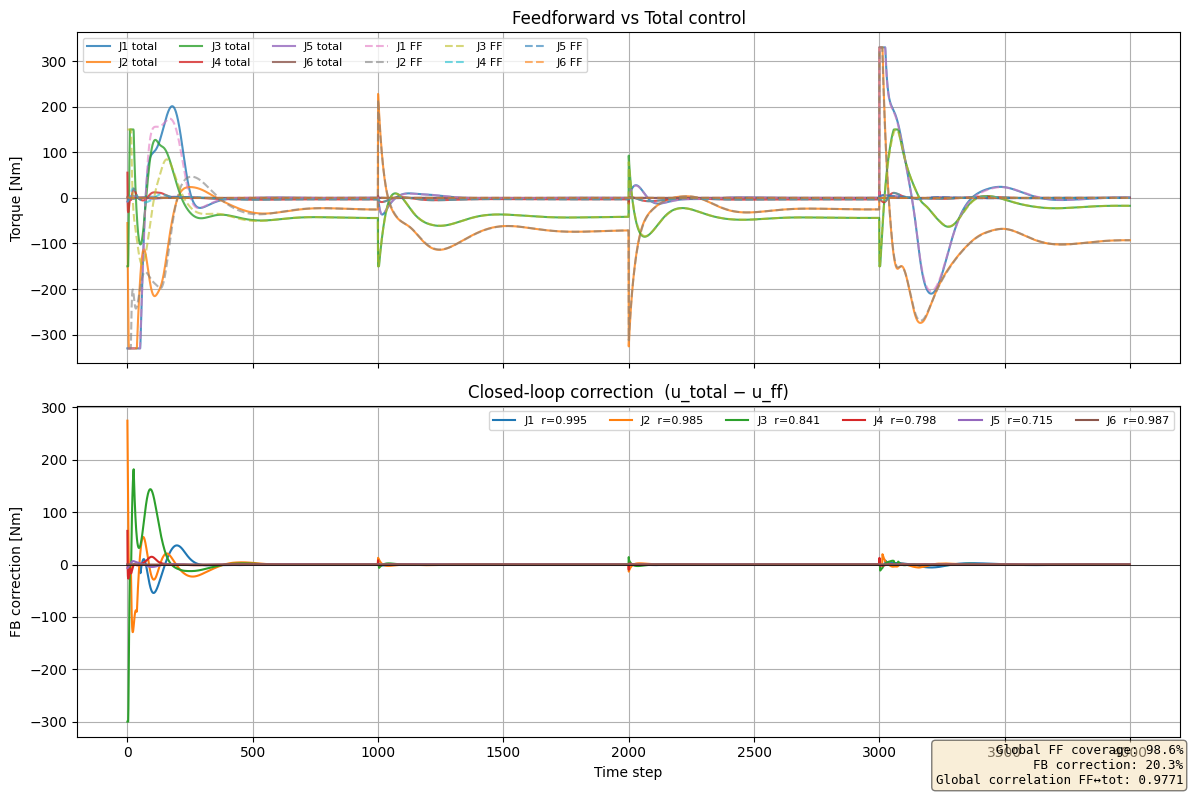

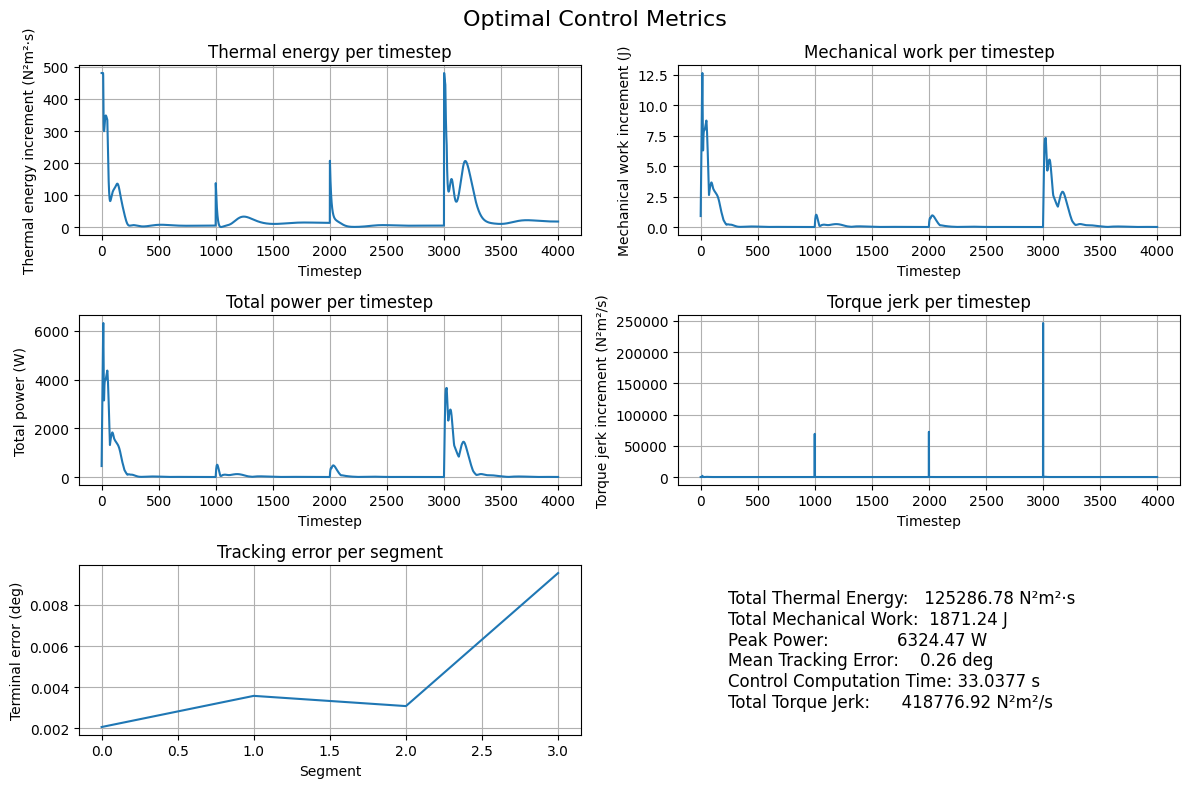

In [ ]:
kp_grids = [
    np.array([5, 20, 60, 150, 400]),
    np.array([5, 20, 60, 150, 400]),
    np.array([5, 20, 60, 150, 400]),
    np.array([1, 5, 15, 40, 100]),
    np.array([1, 5, 15, 40, 100]),
    np.array([1, 5, 15, 40, 100]),
]
ratio_grids = [np.array([0.05, 0.10, 0.15])] * 6
kp_init = np.array([60.0, 60.0, 60.0, 15.0, 15.0, 15.0])
ratio_init = np.array([0.10] * 6)

start_time = time.time()
kp_grid, ratio_grid, score_grid, n_eval = coordinate_grid_search(
    kp_grids, ratio_grids, kp_init, ratio_init, DT, path, n_passes=4)
_, xs, us = evaluate(kp_grid, kp_grid * ratio_grid, DT, path, time_limit=1000, max_error_deg=MAX_ERROR_DEG, get_xs_us=True)
end_time = time.time()
controller_time = end_time - start_time
kd_grid = kp_grid * ratio_grid
print("Grid best score:", score_grid, " evaluations:", n_eval)
print("Grid kp:", np.round(kp_grid, 3))
print("Grid kd:", np.round(kd_grid, 3))
xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=kp_grid, kd=kd_grid)
robot_mj_model.plot_feedback_part(us_real, us)
metrics.plot_metrics(us, xs, DT, path[1:], [1000]*(len(path)-1), controller_time)

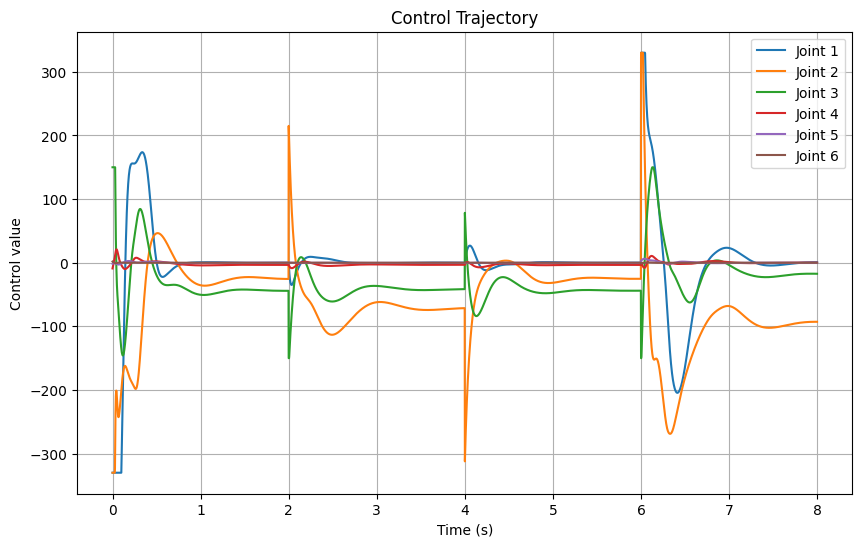

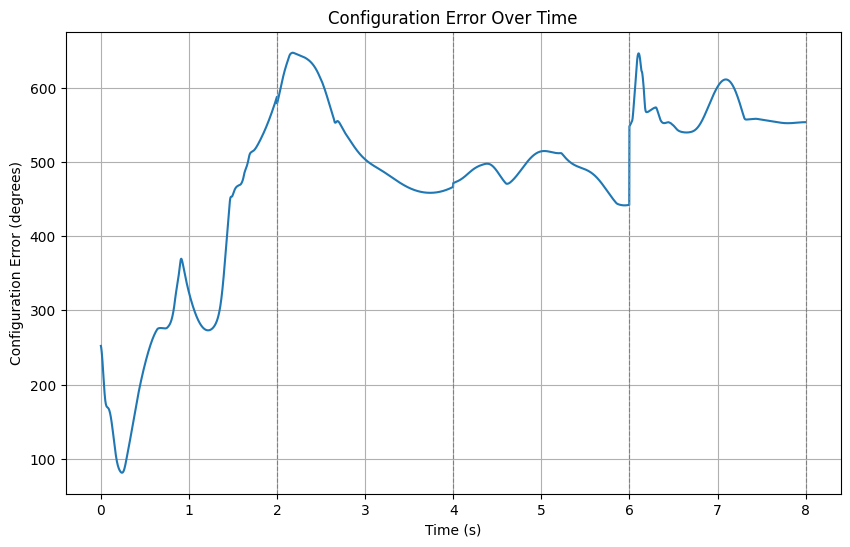

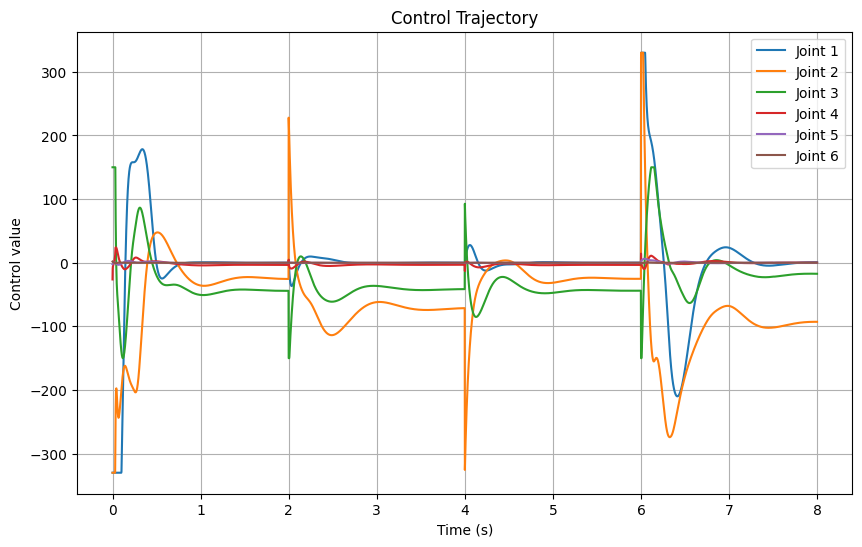

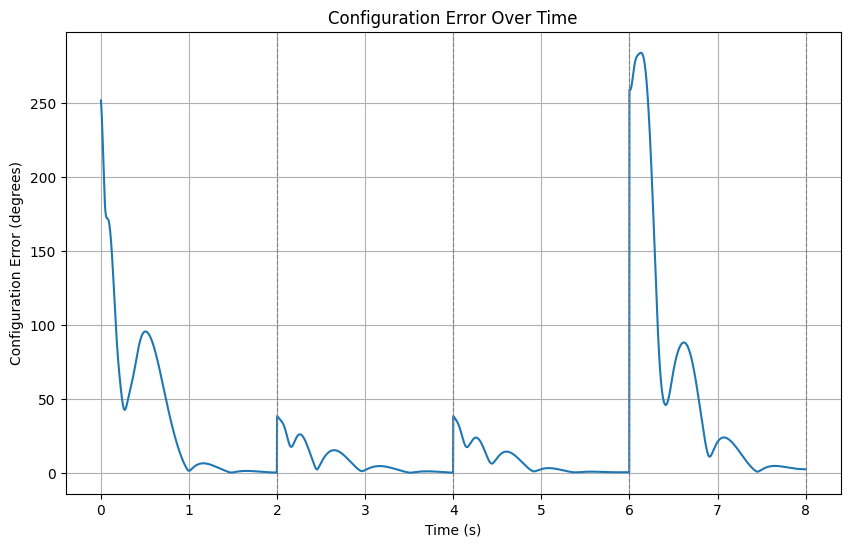

In [3]:
# Visualize Path computed by Mujoco - Open loop control with ideal model
robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Open loop control without feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Closed loop control with feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)



In [3]:
# Found values:
best_per_interp = {
    "linear": {'alpha': 1.0, 
               'interpolation': 'linear', 
               'score': 889325.7838956026, 
               'kp': np.array([400., 400., 400., 100.,   5.,   5.]), 
               'ratio': np.array([0.05, 0.1 , 0.05, 0.05, 0.1 , 0.05])},
    "cubic": {'alpha': 0.8, 
              'interpolation': 'cubic', 
              'score': 32086.88319025388, 
              'kp': np.array([400., 400., 400., 100.,  15.,   5.]), 
              'ratio': np.array([0.15, 0.15, 0.15, 0.15, 0.15, 0.05])},
    "quintic": {'alpha': 0.8, 
                'interpolation': 'quintic', 
                'score': 53272.48748938097, 
                'kp': np.array([400., 400., 400., 100., 100.,   5.]), 
                'ratio': np.array([0.15, 0.15, 0.1 , 0.1 , 0.05, 0.1 ])},
    "trapezoidal": {'alpha': 0.8, 
                    'interpolation': 'trapezoidal', 
                    'score': 43995.74449685817, 
                    'kp': np.array([400., 400., 400., 100.,  15.,   5.]), 
                    'ratio': np.array([0.15, 0.15, 0.15, 0.15, 0.15, 0.05])}
}
best_params = best_per_interp['cubic']
controller_time = 556.8

alpha=0.5  interp=linear        score=5.1569e+06  evals=361
alpha=0.5  interp=cubic         score=1.4370e+05  evals=361
alpha=0.5  interp=trapezoidal   score=1.5527e+05  evals=361
alpha=0.5  interp=quintic       score=2.5596e+05  evals=361
alpha=0.6  interp=linear        score=8.3412e+06  evals=361
alpha=0.6  interp=cubic         score=8.3232e+08  evals=361
alpha=0.6  interp=trapezoidal   score=9.2452e+04  evals=361
alpha=0.6  interp=quintic       score=1.1425e+09  evals=361
alpha=0.8  interp=linear        score=4.4642e+08  evals=361
alpha=0.8  interp=cubic         score=3.2087e+04  evals=361
alpha=0.8  interp=trapezoidal   score=4.3996e+04  evals=361
alpha=0.8  interp=quintic       score=5.3272e+04  evals=361
alpha=1.0  interp=linear        score=8.8933e+05  evals=361
alpha=1.0  interp=cubic         score=1.2470e+09  evals=271
alpha=1.0  interp=trapezoidal   score=1.7132e+09  evals=271
alpha=1.0  interp=quintic       score=4.4847e+08  evals=361

  BEST PER INTERPOLATION METHOD
Interp 

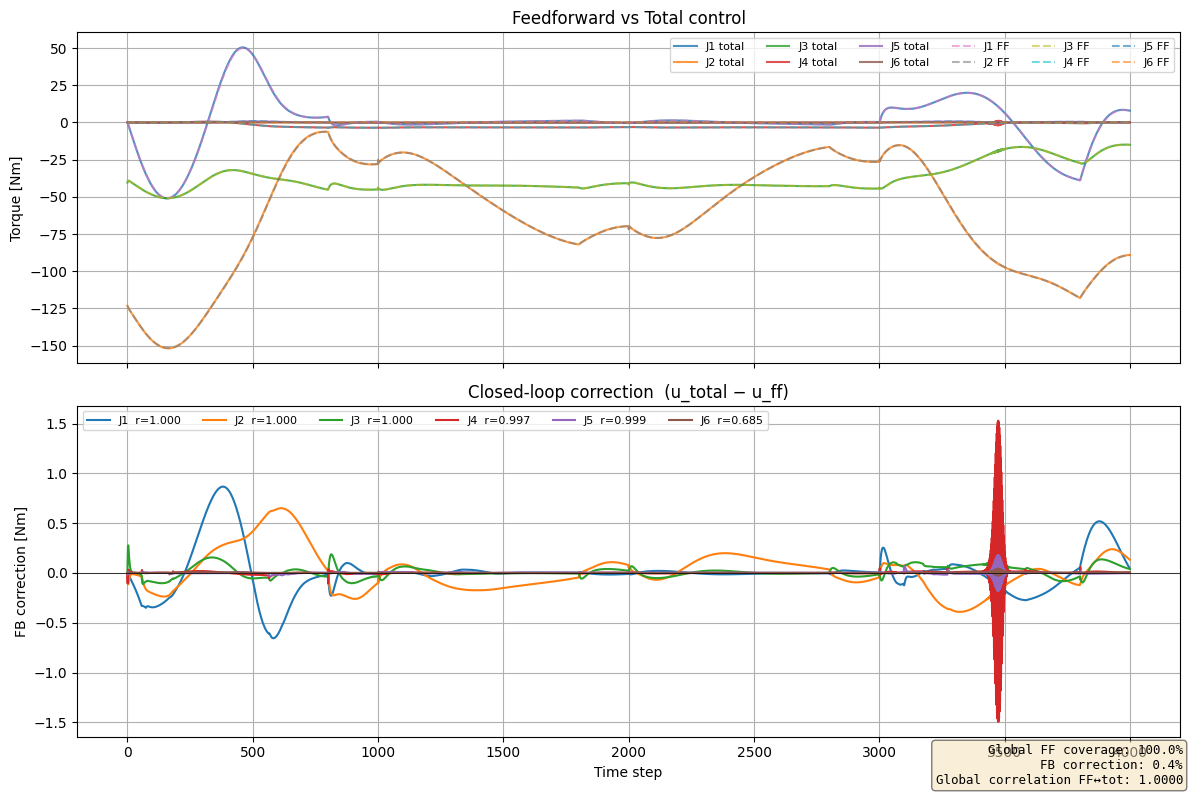

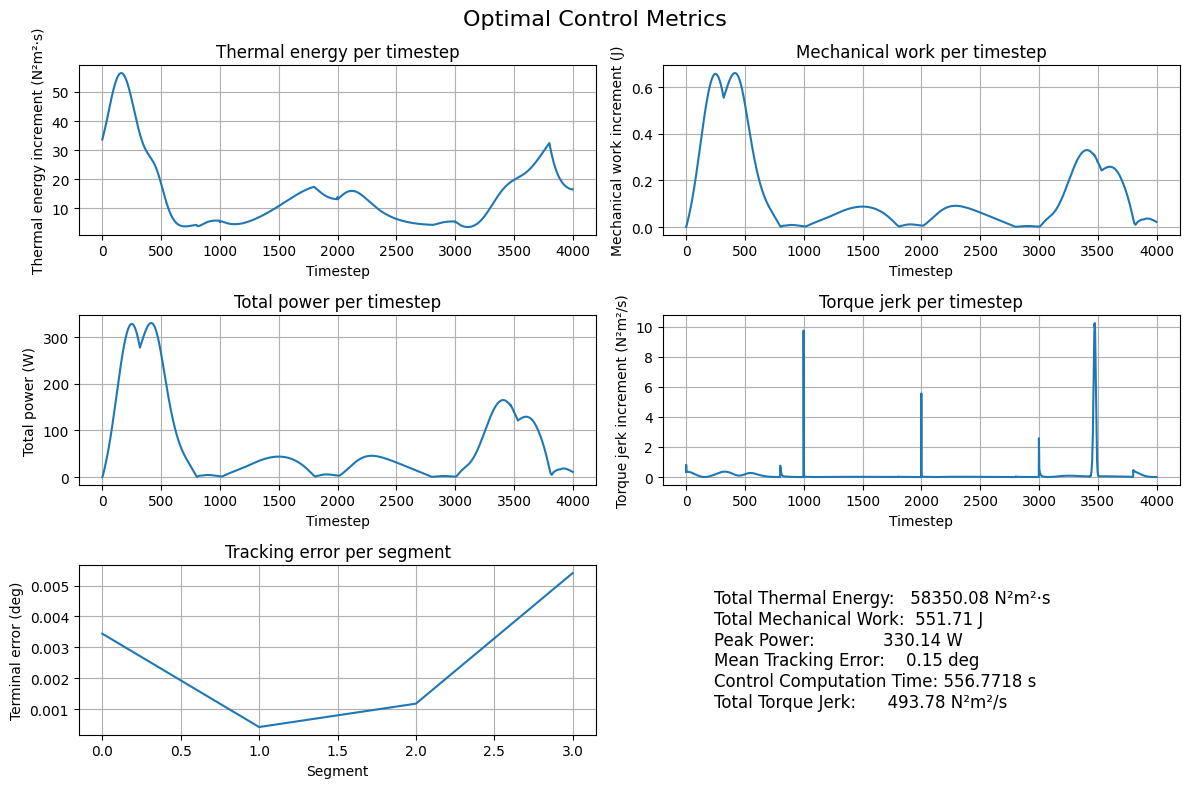

In [ ]:
ALPHA_GRID         = [0.5, 0.6, 0.8, 1.0]
INTERPOLATION_GRID = ["linear", "cubic", "trapezoidal", "quintic"]

kp_grids = [
    np.array([5, 20, 60, 150, 400]),
    np.array([5, 20, 60, 150, 400]),
    np.array([5, 20, 60, 150, 400]),
    np.array([1, 5, 15, 40, 100]),
    np.array([1, 5, 15, 40, 100]),
    np.array([1, 5, 15, 40, 100]),
]
ratio_grids = [np.array([0.05, 0.10, 0.15])] * 6
kp_init    = np.array([60.0, 60.0, 60.0, 15.0, 15.0, 15.0])
ratio_init = np.array([0.10] * 6)

start_time = time.time()
best_score  = float("inf")
best_params = {}
best_per_interp = {interp: {"score": float("inf")} for interp in INTERPOLATION_GRID}
all_results = []

for alpha in ALPHA_GRID:
    for interp in INTERPOLATION_GRID:
        kp_cur, ratio_cur, score_cur, n_eval = coordinate_grid_search(
            kp_grids, ratio_grids, kp_init, ratio_init,
            DT, path, n_passes=4, alpha=alpha, interpolation=interp, verbose=False)
        print(f"alpha={alpha:.1f}  interp={interp:<12}  score={score_cur:.4e}  evals={n_eval}")
        all_results.append(dict(alpha=alpha, interpolation=interp, score=score_cur,
                                kp=kp_cur.copy(), ratio=ratio_cur.copy()))
        entry = dict(alpha=alpha, interpolation=interp,
                     score=score_cur, kp=kp_cur.copy(), ratio=ratio_cur.copy())
        if score_cur < best_per_interp[interp]["score"]:
            best_per_interp[interp] = entry
        if score_cur < best_score:
            best_score  = score_cur
            best_params = entry

end_time = time.time()
controller_time = end_time - start_time

print("\n" + "=" * 70)
print("  BEST PER INTERPOLATION METHOD")
print("=" * 70)
print(f"{'Interp':<14} {'alpha':>6} {'score':>12} {'kp':>40} {'kd':>40}")
print("-" * 70)
for interp, r in best_per_interp.items():
    if r["score"] == float("inf"):
        continue
    print(f"{interp:<14} {r['alpha']:>6.1f} {r['score']:>12.4e}  "
          f"kp={np.round(r['kp'], 1)}  kd={np.round(r['kp'] * r['ratio'], 3)}")

print("\n" + "=" * 70)
print(f"  GLOBAL BEST: alpha={best_params['alpha']}  interpolation={best_params['interpolation']}")
print(f"  score={best_score:.4e}  total wall time={controller_time:.1f}s")
print(f"  kp = {np.round(best_params['kp'], 3)}")
print(f"  kd = {np.round(best_params['kp'] * best_params['ratio'], 3)}")
print("=" * 70)

# Re-evaluate global best config to get trajectories for plotting
kp_best = best_params["kp"]
kd_best = kp_best * best_params["ratio"]
_, xs, us = evaluate(kp_best, kd_best, DT, path,
                     time_limit=1000, max_error_deg=MAX_ERROR_DEG, get_xs_us=True,
                     alpha=best_params["alpha"], interpolation=best_params["interpolation"])
xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=kp_best, kd=kd_best)
robot_mj_model.plot_feedback_part(us_real, us)
metrics.plot_metrics(us_real, xs_real, DT, path[1:], [1000]*(len(path)-1), controller_time)


Joint     Corr FF↔tot  RMS FF %  RMS FB %    MAE FB
-------------------------------------------------------
  1            0.9999     99.6%      1.3%    0.1180
  2            1.0000    100.0%      0.3%    0.1534
  3            1.0000    100.0%      0.2%    0.0455
  4            0.9965     99.9%      4.4%    0.0187
  5            0.9986    100.6%      5.4%    0.0057
  6            0.6839     39.0%     80.2%    0.0021
Global FF coverage: 100.0%   FB correction: 0.4%
Global correlation FF↔tot: 1.0000


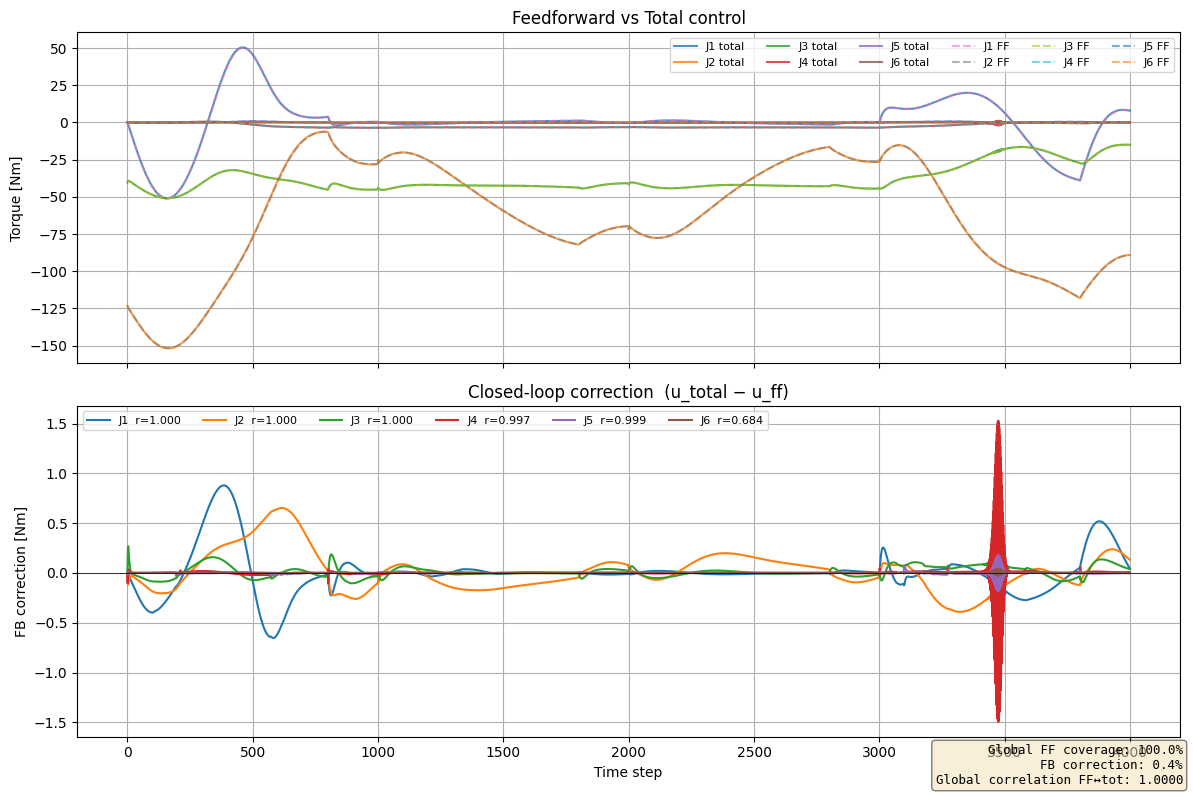

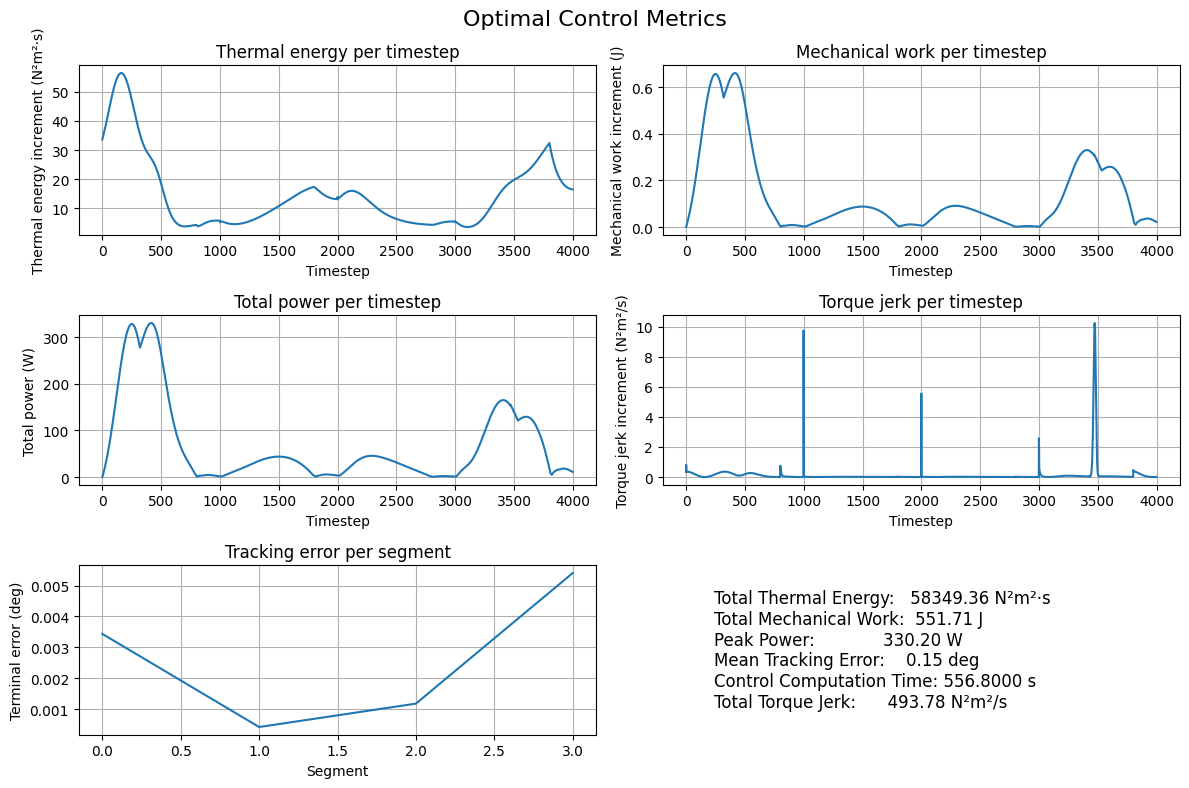

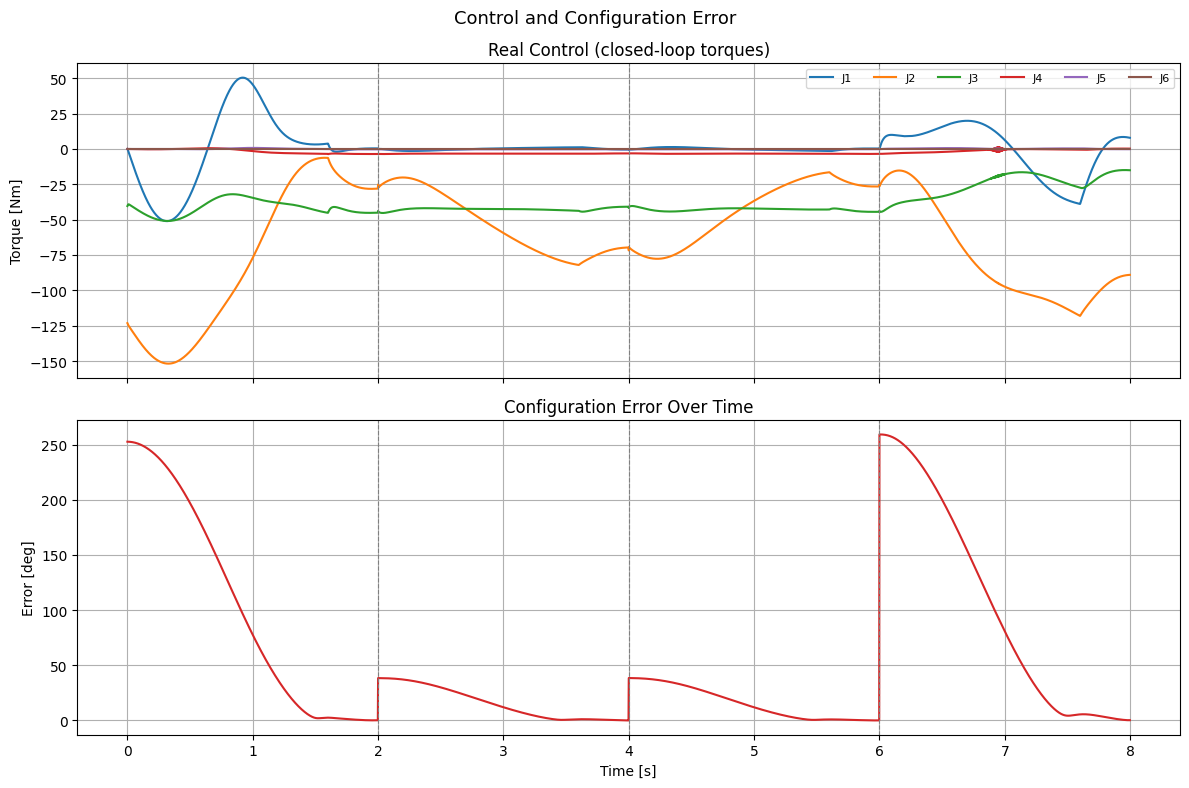

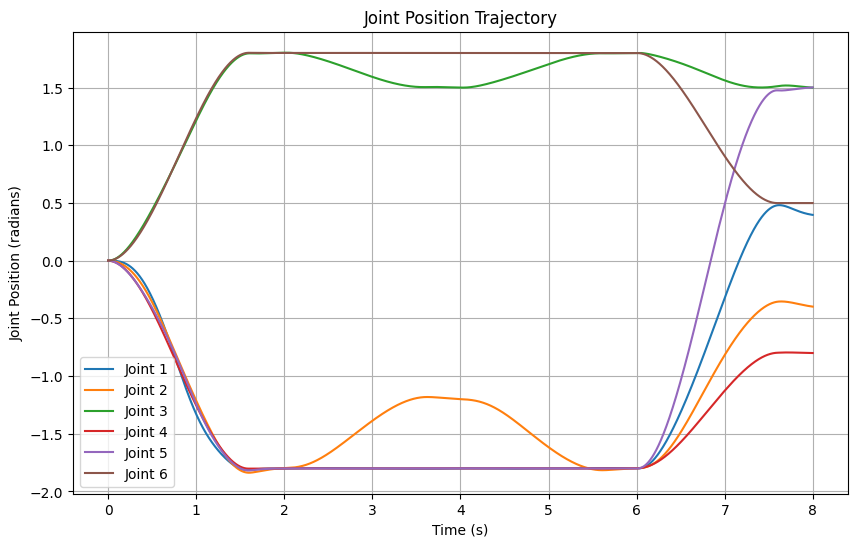

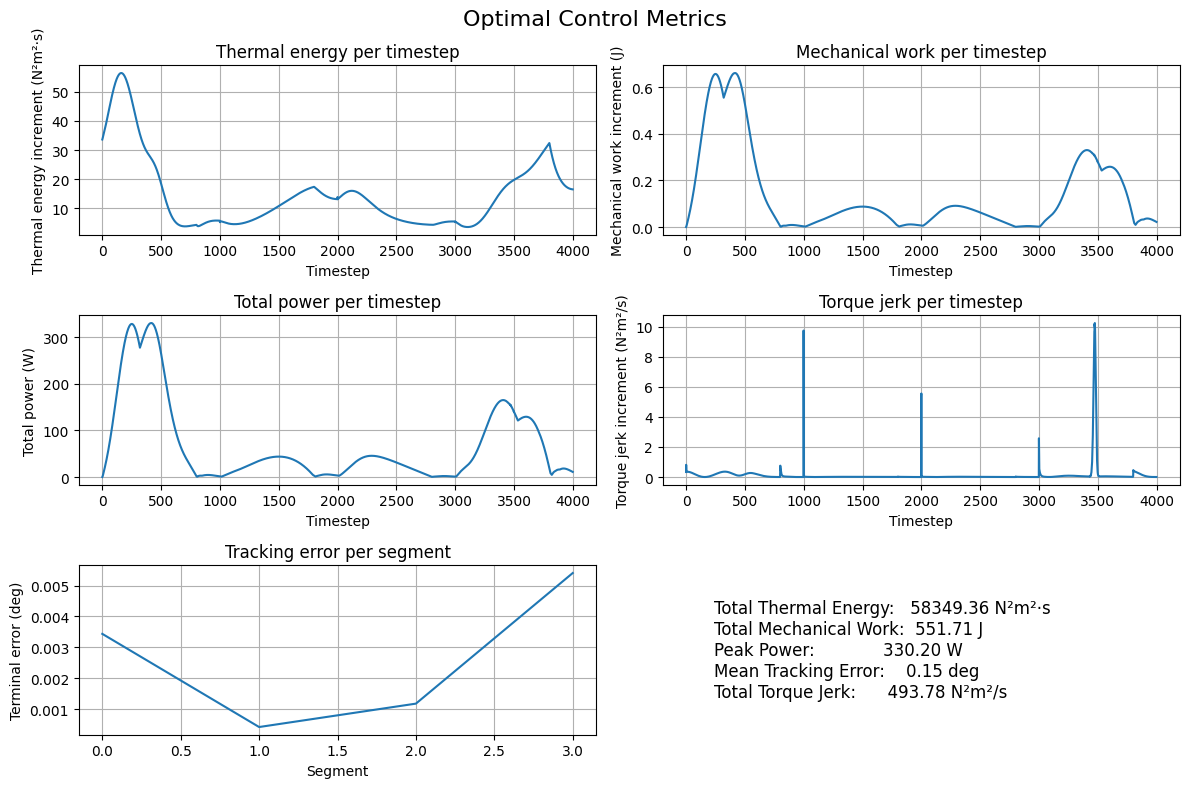

{'thermal_energy': 58349.35857086419,
 'mechanical_work': 551.7139250029581,
 'peak_power': 330.2016013751831,
 'tracking_error': 0.14939975554607327,
 'torque_jerk': 493.78224856794446}

In [5]:
# Re-evaluate global best config to get trajectories for plotting
kp_best = best_params["kp"]
kd_best = kp_best * best_params["ratio"]
_, xs, us = evaluate(kp_best, kd_best, DT, path,
                     time_limit=1000, max_error_deg=MAX_ERROR_DEG, get_xs_us=True,
                     alpha=best_params["alpha"], interpolation=best_params["interpolation"])
robot_mj_model.reset()
xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=kp_best, kd=kd_best)
robot_mj_model.plot_feedback_part(us_real, us)
metrics.plot_metrics(us_real, xs_real, DT, path[1:], [1000]*(len(path)-1), controller_time)
metrics.plot_controls_and_error(us_real, xs_real, DT, path[1:], [1000]*(len(path)-1))
robot_mj_model.plot_position(xs_real, dt=DT)
metrics.summary_metrics(us_real, xs_real, DT, path[1:], [1000]*(len(path)-1))

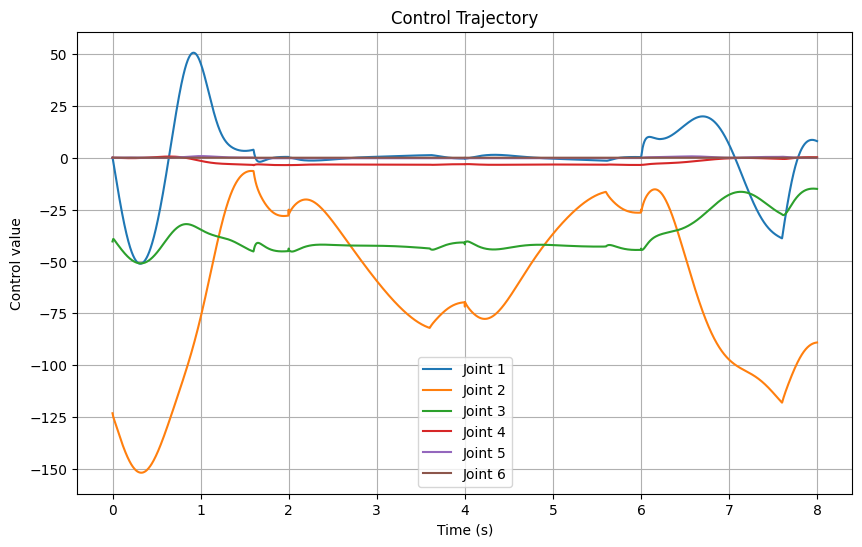

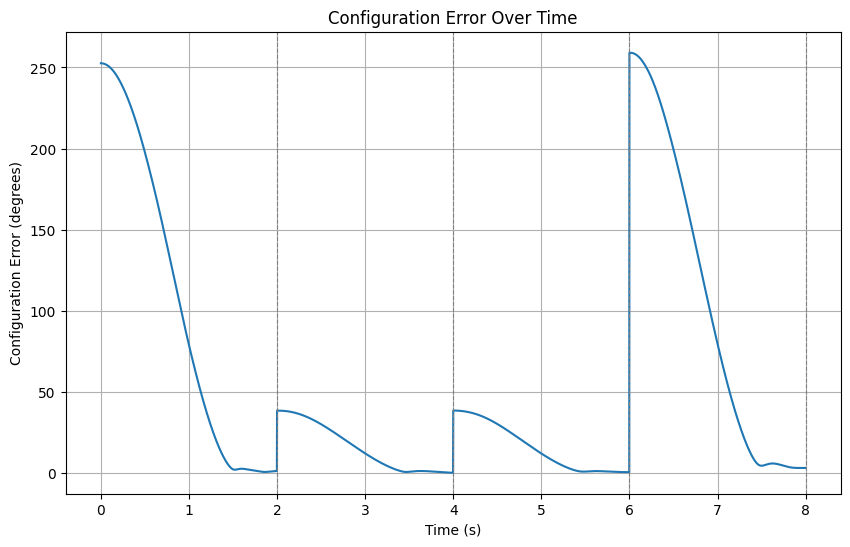

In [ ]:
# Visualize Path computed by Mujoco - Open loop control with ideal model
# robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Open loop control without feedback
# xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
# robot_mj_model.plot_controls(us_real, dt=DT)
# robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Closed loop control with feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plo
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)